# Fitting and plotting of modified exponential curve

--- Practical 1: Modified Exponential Curve ---
Dataset loaded successfully!

Calculating Initial Guesses for Parameters (a, b, c)...
Initial Guess values -> a: 316.16, b: 0.0005, c: 316.16

Fitting the curve to the data...

********************************************************
Optimized values for best fit: a = 58.4012, b = 4.3788e-05, c = 255.2024
********************************************************

Covariance matrix of the parameters (a, b, c):
[[ 2.29881233e-01 -1.10734992e-07 -2.48958122e-01]
 [-1.10734992e-07  5.36711385e-14  1.19498013e-07]
 [-2.48958122e-01  1.19498013e-07  2.70451945e-01]]
********************************************************


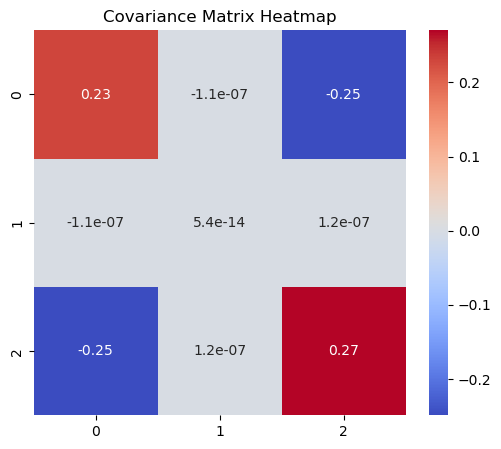


Coefficient of Determination (R^2 Score) = 0.9923


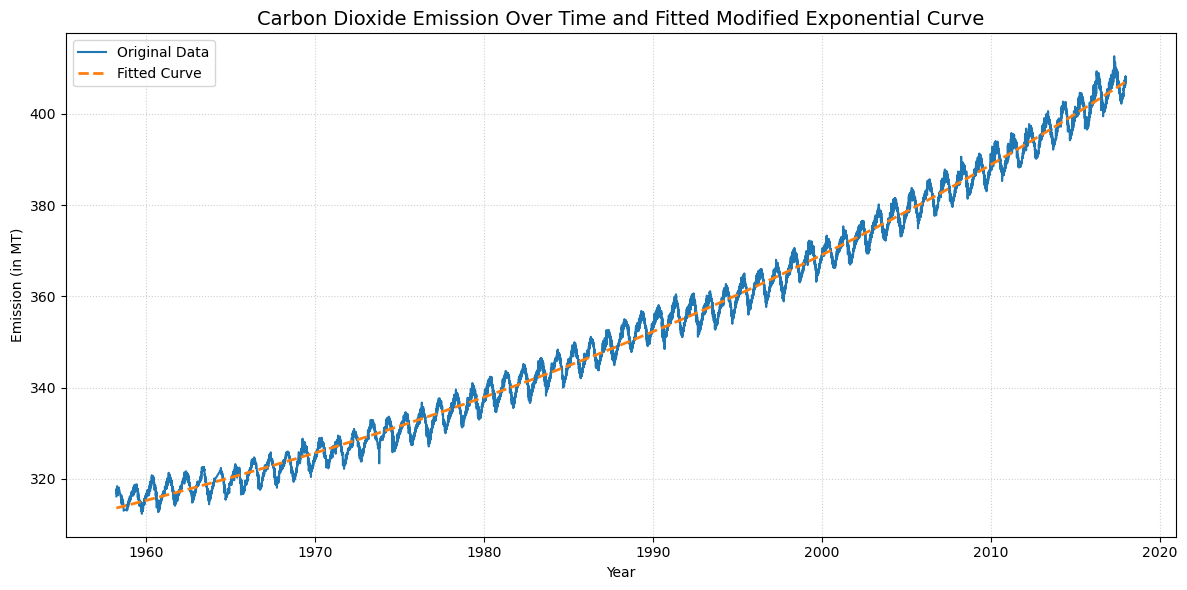

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

def fit_modified_exponential():
    print("--- Practical 1: Modified Exponential Curve ---")
    # 0. Load Dataset 
    path = r"C:\Users\Mahesh Khairnar\Time Series Analysis and Forecasting\Practical Datasets\co2-ppm-daily.csv"
    CO2_emission = pd.read_csv(path)

    # 1. Data Preparation 
    CO2_emission['date'] = pd.to_datetime(CO2_emission['date'])
    CO2_emission.sort_values('date', inplace=True)
    x_data = CO2_emission['date']
    y_data = CO2_emission['value']
    
    # Machine Learning math cannot understand calendar dates like "1958-03-30".
    # We must convert the dates into numerical values (number of days since the very first date).
    CO2_emission['Time'] = (CO2_emission['date'] - CO2_emission['date'].min()).dt.days
    x_numerical = CO2_emission['Time']

    # 2. Define the model for the modified exponential curve: y = a * e^(bt) + c
    def mod_exp_func(t, a, b, c):
        return a * np.exp(b * t) + c

    print("\nCalculating Initial Guesses for Parameters (a, b, c)...")
    
    # Initial guess for 'a' and 'c' (Using .iloc[0] ensures it safely gets the first row even after sorting)
    a_guess = y_data.iloc[0]
    c_guess = y_data.iloc[0]
    
    # 3. Calculate the middle index to find a good guess for 'b'
    if len(x_data) % 2 == 0:
        central_index = len(x_data) // 2 - 1 
    else:
        central_index = len(x_data) // 2
        
    centre_value_of_x = x_data.iloc[central_index]
    
    # Extract the year from the center date to guess 'b'
    timestamp_obj = pd.Timestamp(centre_value_of_x)
    b_guess = 1 / timestamp_obj.year
    
    print(f"Initial Guess values -> a: {a_guess:.2f}, b: {b_guess:.4f}, c: {c_guess:.2f}")

    print("\nFitting the curve to the data...")
    p0 = (a_guess, b_guess, c_guess)
    
    # curve_fit does the heavy mathematical lifting to find the optimal a, b, and c
    popt, pcov = curve_fit(mod_exp_func, x_numerical, y_data, p0=p0, maxfev=8000)
    
    print(f"Optimized values for best fit: a = {popt[0]:.4f}, b = {popt[1]:.4e}, c = {popt[2]:.4f}")
    print("\nCovariance matrix of the parameters (a, b, c):")
    print(pcov)

    # 4. Plot the Covariance Matrix Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(pcov, cmap='coolwarm', annot=True)
    plt.title("Covariance Matrix Heatmap")
    plt.show()

    # 5. Use the mathematically optimized parameters to generate the trend line (y_pred)
    y_pred = mod_exp_func(x_numerical, *popt)
    
    # Calculate R-Squared Score to prove mathematical accuracy
    r_squared = r2_score(y_data, y_pred)
    print(f"\nCoefficient of Determination (R^2 Score) = {r_squared:.4f}")

    # 6. Plot the Original Data vs Fitted Curve
    plt.figure(figsize=(12, 6))
    plt.plot(x_data, y_data, label='Original Data', color='tab:blue')
    plt.plot(x_data, y_pred, '--', label='Fitted Curve', color='tab:orange', linewidth=2)
    
    plt.title('Carbon Dioxide Emission Over Time and Fitted Modified Exponential Curve', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Emission (in MT)')
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    fit_modified_exponential()

# VIVA Q&A 


**1. What is the equation of a modified exponential curve?**

* **Answer:** The equation is $y = a \cdot e^{bt} + c$. It is simply a standard exponential curve ($y = a \cdot e^{bt}$) with an extra constant "$c$" added to it.

**2. Which Python function did you use to fit this curve to your dataset?**

* **Answer:** I used the `curve_fit` function, which is imported from the `scipy.optimize` library.

**3. Why do we need to provide "initial guesses" (like `a_guess`, `b_guess`, `c_guess`) in the code?**

* **Answer:** The `curve_fit` function uses a trial-and-error method to find the best curve. Giving it a good starting point (initial guesses) helps the computer find the correct answer much faster and prevents errors.

# Practical 1: Modified Exponential Curve (Viva Guide)

## 1. The Problem Statement (The "What" and "Why")

## The Scenario: You have a dataset tracking Carbon Dioxide (CO2) emissions over several decades.The Problem: CO2 emissions do not just grow steadily in a straight line; they compound and grow faster over time. This is known as Exponential Growth.The Solution: We want to find a mathematical curve that perfectly overlays this growth so we can measure the trend and predict future emissions. We use a Modified Exponential Curve ($y = A \cdot e^{Bt} + C$) because the "C" allows the curve to shift up or down to match the baseline level of CO2 in the atmosphere.

## 2. Core Viva Questions

## Q: Why do we use scipy.optimize.curve_fit? Answer: Unlike a simple moving average, fitting an exponential curve is non-linear. The curve_fit function acts as an advanced math engine. It takes our raw data and rapidly tests thousands of combinations for $A$, $B$, and $C$ until it finds the formula that has the minimum error.

## Q: Why did you have to write code to "guess" the initial values (a_guess, b_guess, c_guess)? Answer: Because curve_fit is a non-linear optimizer, it needs a starting point to begin its search. If we give it a completely blank slate, the algorithm might get confused and fail to converge. Giving it a logical starting guess (like using the first data point for $A$ and $C$) helps the computer find the perfect answer much faster.

## Q: What is the significance of the Covariance Matrix Heatmap? Answer: The covariance matrix tells us how reliable our calculated parameters ($A$, $B$, $C$) are.The Diagonal values: Show the variance. Low variance means our parameter estimates are highly precise.The Off-diagonal values: Show how the parameters affect each other. If one goes up, does the other go down?

## Q: Why do we calculate $x\_numerical$ (days since start) instead of just using the Dates? Answer: Mathematical algorithms like curve_fit only understand numbers (floats/integers). They cannot do algebra on calendar strings like "1958-03-30". We subtract the minimum date from every row to create a numerical timeline (Day 0, Day 1, Day 2...).

## Q: What does the $R^2$ (R-Squared) score tell you? Answer: It is the Coefficient of Determination. An $R^2$ of 0.99 means that 99% of the variation in CO2 emissions is perfectly explained by our fitted exponential curve. It proves our model is incredibly accurate.